<a href="https://colab.research.google.com/github/rontho14/MiniWaze/blob/main/Implementa%C3%A7%C3%A3o_do_Google_Maps_Waze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando as libs

In [ ]:
!pip install -q osmnx # ==1.2.2
!pip install -q networkx  # ==3.0
!pip install matplotlib
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 3.1 MB/s eta 0:00:00


Como encontrar distância entre dois pontos pelas latitudes e longitudes:

d=acos(sin(lat1)*sin(lat2)+cos(lat1)*cos(lat2)*cos(lon2-lon1))*6371

(6371 é o raio da Terra em km; latitudes e longitudes estão em graus)

In [ ]:
from math import acos, sin, cos, pi

def distanceKm(p1, p2):
  conv = pi/180  # para converter de graus para radianos
  lat1, lon1 = p1
  lat2, lon2 = p2
  d = d=acos(sin(lat1*conv)*sin(lat2*conv)+cos(lat1*conv)*cos(lat2*conv)*cos(lon2*conv-lon1*conv))*6371
  return d

Consulta à API do OpenStreetMap para encontrar a latitude e longitude de um endereço ou ponto de interesse:

> Add blockquote



In [ ]:
from unidecode import unidecode
from urllib.request import Request, urlopen
import json

def getCoordinates(address):
  address = unidecode(address)  # retirando os acentos
  address = address.replace(' ', '+')
  url = "https://nominatim.openstreetmap.org/search?q=" + address + "&format=json"
  req = Request(
    url,
    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
  )
  response = urlopen(req)
  data_json = json.loads(response.read())
  return float(data_json[0]["lat"]), float(data_json[0]["lon"])

Vamos escolher 2 pontos de interesse:

In [ ]:
p1 = getCoordinates("Instituto Mauá de Tecnologia")
p2 = getCoordinates("Park Shopping São Caetano")
distancia = 1000 * distanceKm(p1,p2)
print(f'{distancia:.1f} m')

2562.3 m


Algoritmo A* e Heurística

In [ ]:
import queue as Q
import math
import heapq

# Calcula heurística -> distância em linha reta
def dist(nodo1, nodo2):
    (lat1, lon1) = (G.nodes[nodo1]['y'], G.nodes[nodo1]['x'])
    (lat2, lon2) = (G.nodes[nodo2]['y'], G.nodes[nodo2]['x'])
    return math.sqrt((lat2 - lat1)**2 + (lon2 - lon1)**2)

# Algoritmo A*
def astar(nodo_inicio, nodo_fim):
    pq = [(0, nodo_inicio)]
    parent = {nodo_inicio: None}
    g_score = {nodo: float('inf') for nodo in G.nodes}
    g_score[nodo_inicio] = 0

    while pq:
        _, current = heapq.heappop(pq)
        if current == nodo_fim:
            break
        for neighbor in G.neighbors(current):
            tentative_g_score = g_score[current] + dist(current, neighbor)
            if tentative_g_score < g_score[neighbor]:
                parent[neighbor] = current
                g_score[neighbor] = tentative_g_score
                # A*: f = g + h
                f_score = tentative_g_score + dist(neighbor, nodo_fim)
                # Alteração para transformar em Greedy Search (Gananciosa)
                # f = 0 + h (ignoro o quanto já andei)
                # f_score = 0 + dist(neighbor, nodo_fim)
                heapq.heappush(pq, (f_score, neighbor))

    if current == nodo_fim:
        path = []
        while current is not None:
            path.append(current)
            current = parent[current]
        path.reverse()
        return path
    else:
        return None

Maps / Waze:

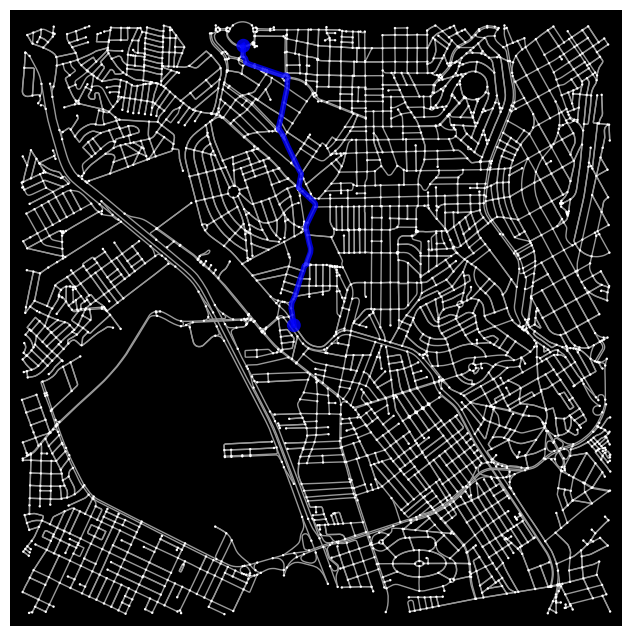

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Coordenadas inicial e final
coord_inicio = p1
coord_fim = p2

# Importar mapa como grafo
G = ox.graph_from_point(coord_inicio, dist=distancia, network_type='drive')

# Transforma a coordenada em ponto
nodo_inicio = ox.distance.nearest_nodes(G, coord_inicio[1], coord_inicio[0])
nodo_fim = ox.distance.nearest_nodes(G, coord_fim[1], coord_fim[0])

# Passa para o A*
caminho = astar(nodo_inicio, nodo_fim)

# Se achar o caminho printa no mapa
if caminho:
    fig, ax = ox.plot_graph_route(G, caminho, route_color='blue',
                                  route_linewidth=4, node_size=3, bgcolor='black',
                                  route_alpha=0.8)
    plt.show()
else:
    print("Caminho não encontrado")

### 1. Adicionando Elevação ao Grafo
Vamos usar a API do Open-Elevation para atribuir altitude a cada nó do nosso mapa.

In [ ]:
import requests
import osmnx as ox

# 1. Configura o template da URL para usar o Open-Elevation
ox.settings.elevation_url_template = "https://api.open-elevation.com/api/v1/lookup?locations={locations}"

# 2. Chama a função usando as configurações globais
G = ox.elevation.add_node_elevations_google(G, api_key=None, batch_size=100, pause=0.5)

# 3. Adiciona a inclinação (grade) às arestas após obter as altitudes
G = ox.elevation.add_edge_grades(G)

print("Elevações e inclinações adicionadas com sucesso!")

Elevações e inclinações adicionadas com sucesso!


### 2. Definindo a Função de Custo Energético
Aqui definimos que subidas são mais 'caras' que trajetos planos.
$Custo = Distância \times (1 + \max(0, grade)^2)$

In [ ]:
def energy_cost(u, v, data):
    length = data.get('length', 0)
    grade = data.get('grade', 0)

    # Se a inclinação for positiva (subida), aumentamos o custo exponencialmente
    # Se for negativa (descida), o custo é apenas a distância (ou reduzido levemente)
    if grade > 0:
        penalty = 1 + (grade * 10) ** 2  # Penalidade quadrática para subidas íngremes
    else:
        penalty = 1 # Descidas não gastam energia extra

    return length * penalty

### 3. A* com Peso de Eficiência Energética
Vamos rodar o algoritmo comparando a rota de menor distância vs a rota de menor esforço.

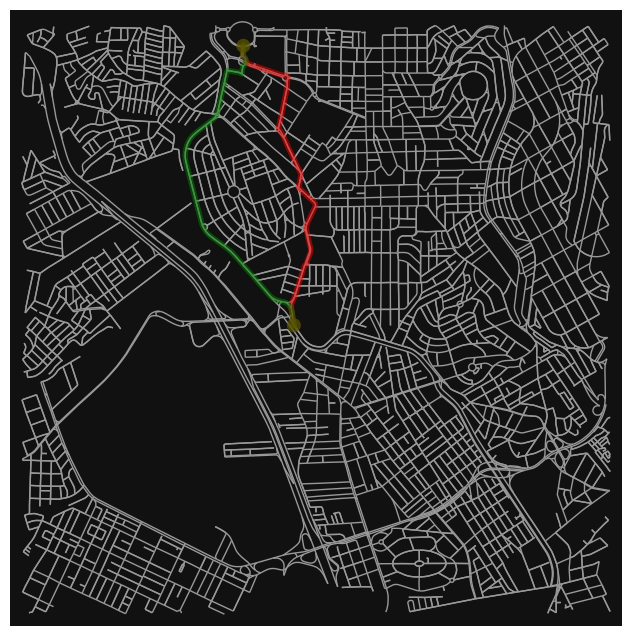

Vermelho: Menor Distância | Verde: Menor Inclinação


In [ ]:
# Rota Padrão (Menor Distância)
rota_distancia = nx.astar_path(G, nodo_inicio, nodo_fim, weight='length')

# Rota Eficiente (Menor Inclinação/Energia)
rota_energia = nx.astar_path(G, nodo_inicio, nodo_fim, weight=energy_cost)

# Visualização Comparativa
fig, ax = ox.plot_graph_routes(G, [rota_distancia, rota_energia],
                                route_colors=['red', 'green'],
                                route_linewidth=4, node_size=0)
print("Vermelho: Menor Distância | Verde: Menor Inclinação")

### 4. Análise de Resultados e Validação da Hipótese
Vamos calcular a distância total e a subida acumulada para ambas as rotas.

In [ ]:
def get_route_stats(route):
    # No OSMnx v2, route_to_gdf recebe apenas G e route e retorna o GeoDataFrame completo
    edges = ox.routing.route_to_gdf(G, route)

    dist_total = edges['length'].sum()

    # 'grade' pode conter NaN se a elevação falhou para algum nó; preenchemos com 0 por segurança
    grades = edges['grade'].fillna(0)
    lengths = edges['length']

    # Cálculo do esforço: soma ponderada das subidas (grades positivas)
    subida_acumulada = sum(max(0, g) * l for g, l in zip(grades, lengths))

    return dist_total, subida_acumulada

# Recalcula as estatísticas usando a lógica corrigida
dist_std, climb_std = get_route_stats(rota_distancia)
dist_energy, climb_energy = get_route_stats(rota_energia)

print("--- RESULTADOS COMPARATIVOS ---")
print(f"Rota Vermelha (Menor Distância):")
print(f"Distância: {dist_std:.2f} m")
print(f"Esforço de Subida: {climb_std:.2f} unidades de elevação")

print(f"\nRota Verde (Eficiência Energética):")
print(f"Distância: {dist_energy:.2f} m")
print(f"Esforço de Subida: {climb_energy:.2f} unidades de elevação")

# Cálculo da Melhoria Percentual
economia = (1 - (climb_energy / climb_std)) * 100 if climb_std > 0 else 0
print(f"\nConclusão: A rota eficiente reduziu o esforço de subida em {economia:.1f}%.")

--- RESULTADOS COMPARATIVOS ---
Rota Vermelha (Menor Distância):
Distância: 2888.39 m
Esforço de Subida: 36.00 unidades de elevação

Rota Verde (Eficiência Energética):
Distância: 3112.28 m
Esforço de Subida: 12.00 unidades de elevação

Conclusão: A rota eficiente reduziu o esforço de subida em 66.7%.


### Unidades de Energia
Como não estamos simulando um veículo específico (com peso e motor definidos), o valor retornado pela nossa função `energy_cost` é um **Índice de Custo Relativo**.

*   **Na Rota Vermelha (Shortest):** O custo é dominado pela distância, mas 'paga-se caro' em cada metro de subida devido à penalidade quadrática.
*   **Na Rota Verde (Efficient):** O custo total é menor porque, embora a distância seja maior, a penalidade por inclinação é evitada.

Para converter isso em **kWh**, por exemplo, a fórmula precisaria ser expandida para:
$$Energia (J) = m \cdot g \cdot \Delta h + \text{Atrito} + \text{Resistência do Ar}$$

No nosso caso, o valor serve como uma ferramenta de **comparação de esforço** entre os dois trajetos.

In [ ]:
def calculate_total_energy(route):
    # Obtemos o GeoDataFrame das arestas da rota
    edges = ox.routing.route_to_gdf(G, route)
    total_energy = 0

    # Iteramos por cada aresta para calcular o custo usando nossa função
    for _, edge in edges.iterrows():
        data = {
            'length': edge['length'],
            'grade': edge.get('grade', 0)
        }
        total_energy += energy_cost(None, None, data)

    return total_energy

# Calculando os custos totais
energy_total_std = calculate_total_energy(rota_distancia)
energy_total_efficient = calculate_total_energy(rota_energia)

print("--- CUSTO ENERGÉTICO TOTAL ---")
print(f"Rota Vermelha (Shortest): {energy_total_std:.2f} unidades de energia")
print(f"Rota Verde (Efficient): {energy_total_efficient:.2f} unidades de energia")

economia_real = (1 - (energy_total_efficient / energy_total_std)) * 100
print(f"\nMelhoria Real no custo total: {economia_real:.1f}%")

--- CUSTO ENERGÉTICO TOTAL ---
Rota Vermelha (Shortest): 3541.92 unidades de energia
Rota Verde (Efficient): 3140.13 unidades de energia

Melhoria Real no custo total: 11.3%


Agradecimentos aos alunos Gabriel Garofalo, Felipe Boacnin e Leonardo Zollner, do IMT